<a href="https://colab.research.google.com/github/SamiraKheradmand/IASC-ASCE-Transformer-SHM/blob/main/notebooks/02_split_methods/chronological/Split_statistical_signature_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chronological Acquisition Fingerprint Diagnostic

## Objective

This notebook investigates whether statistical patterns observed in the
disconnected system-noise channel (DA16) are also present in the connected
structural sensors DA04–DA15.

The analysis uses the same chronological preprocessing protocol as the main
Transformer experiments, but it is a diagnostic analysis rather than a
classification experiment.

Primary statistical features:
- RMS
- STD
- Peak-to-Peak
- Kurtosis

DA16 is used only as a disconnected reference channel.

# 1. Setup and Data Loading

In [1]:
import os
import scipy.io as sio
from scipy.io.matlab._mio5_params import mat_struct
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from pathlib import Path
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
from pathlib import Path

import numpy as np
import scipy.io as sio


# مسیر فایل‌ها
DATA_DIR = Path("/content/drive/MyDrive/ASCE_IASC/MAT_data")

# فقط 16 سنسور واقعی سازه
CHANNELS = [f"DA{i:02d}" for i in range(1, 17)]

# پیدا کردن فایل‌های 9 حالت سازه
mat_files = sorted(DATA_DIR.glob("shm*.mat"))

print("Folder exists:", DATA_DIR.exists())
print("Number of files:", len(mat_files))
print("Number of channels:", len(CHANNELS))


def load_ambient_file(file_path):
    """
    خواندن یک فایل Ambient از داده‌های IASC-ASCE
    """

    mat = sio.loadmat(file_path,squeeze_me=True,struct_as_record=False)

    dasy = mat["dasy"]
    dasy_dscr = mat["dasy_dscr"]
    fs = float(mat["fsdasy"])

    signals = []
    descriptions = []

    for i, channel in enumerate(CHANNELS, start=1):

        signal = np.asarray(getattr(dasy, channel)).reshape(-1)

        description_name = f"DAdscr{i:02d}"
        description = getattr(dasy_dscr, description_name)

        signals.append(signal)
        descriptions.append(description)

    # شکل خروجی:
    # (تعداد نمونه‌های زمانی، تعداد سنسورها)
    X_raw = np.column_stack(signals)

    return X_raw, fs, descriptions

Folder exists: True
Number of files: 9
Number of channels: 16


## 1.1 DA16 Metadata Check

DA16 is retained as a negative-control reference channel.
Its metadata should identify it as disconnected system noise in all nine cases.

In [4]:
all_cases = {}

for file_path in mat_files:

    case_name = file_path.stem
    case_number = int(case_name[3:5])

    X_raw, fs, descriptions = load_ambient_file(file_path)

    all_cases[case_name] = {
        "X_raw": X_raw,
        "fs": fs,
        "channels": CHANNELS.copy(),
        "descriptions": descriptions,
        "case_number": case_number,
        "label": case_number - 1,
        "file_path": file_path
    }

    print(
        f"{case_name} | "
        f"shape: {X_raw.shape} | "
        f"fs: {fs} Hz | "
        f"label: {case_number - 1}"

    )
print( f"description: {pd.DataFrame(descriptions)}")

shm01a | shape: (60000, 16) | fs: 200.0 Hz | label: 0
shm02a | shape: (60000, 16) | fs: 200.0 Hz | label: 1
shm03a | shape: (60000, 16) | fs: 200.0 Hz | label: 2
shm04a | shape: (60000, 16) | fs: 200.0 Hz | label: 3
shm05a | shape: (60000, 16) | fs: 200.0 Hz | label: 4
shm06a | shape: (45568, 16) | fs: 200.0 Hz | label: 5
shm07a | shape: (180000, 16) | fs: 200.0 Hz | label: 6
shm08a | shape: (180000, 16) | fs: 200.0 Hz | label: 7
shm09a | shape: (180000, 16) | fs: 200.0 Hz | label: 8
description:                                                     0
0        Base West side - EPI sensor X direction (N+)
1           Base Center - EPI sensor Y direction (W+)
2        Base East side - EPI sensor X direction (N+)
3         1st Floor - N/S EPI Sensor at West end (N+)
4           1st Floor - E/W FBA Sensor at Center (W+)
5         1st Floor - N/S FBA Sensor at East end (N+)
6         2nd Floor - N/S FBA Sensor at West end (N+)
7           2nd Floor - E/W EPI Sensor at Center (W+)
8         2n

In [5]:
print(all_cases["shm01a"]["X_raw"].shape)
print(all_cases["shm01a"]["channels"])


(60000, 16)
['DA01', 'DA02', 'DA03', 'DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15', 'DA16']


# 2. Chronological Evaluation Protocol

The same chronological preprocessing used in the main Transformer experiment
is retained to ensure that the statistical diagnostic is evaluated under the
same temporal structure.

## 2.1 Chronological 60/20/20 Split

In [6]:
# ============================================================
# Step 2: Chronological split and Butterworth high-pass filter
# Filter is applied separately to Train, Validation and Test
# ============================================================

import pandas as pd
from scipy.signal import butter, sosfiltfilt


# ----------------------------
# Split settings
# ----------------------------
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20

GAP_SEC = 0
EDGE_SEC = 2


# ----------------------------
# High-pass filter settings
# ----------------------------
CUTOFF = 0.1
ORDER = 2


def highpass_filter(X, fs):

    """
    Apply a Butterworth high-pass filter to all sensor channels.
    X shape:(samples, sensors)
    """

    sos = butter(N=ORDER, Wn=CUTOFF,btype="highpass",fs=fs,output="sos")
    X_filtered = sosfiltfilt(sos,X,axis=0)

    return X_filtered

## 2.2 Independent High-Pass Filtering and Edge Trimming

In [7]:
train_data = {}
val_data = {}
test_data = {}

split_report = []

for case_name in sorted(all_cases.keys()):

    # Raw data
    X = all_cases[case_name]["X_raw"]
    fs = all_cases[case_name]["fs"]

    n_samples = len(X)

    gap_size = int(GAP_SEC * fs)
    edge_size = int(EDGE_SEC * fs)

    # ----------------------------
    # Chronological split boundaries
    # ----------------------------
    train_end = int(TRAIN_RATIO * n_samples)

    val_start = train_end + gap_size
    val_end = val_start + int(VAL_RATIO * n_samples)

    test_start = val_end + gap_size

    if test_start >= n_samples:
        raise ValueError(f"{case_name}: signal is too short for this gap.")

    # ----------------------------
    # Split raw signal
    # ----------------------------
    X_train_raw = X[:train_end]
    X_val_raw = X[val_start:val_end]
    X_test_raw = X[test_start:]

    # Check split lengths
    if min(len(X_train_raw), len(X_val_raw), len(X_test_raw)) <= 2 * edge_size:
        raise ValueError(f"{case_name}: EDGE_SEC is too large.")

    # ----------------------------
    # Filter each split separately
    # ----------------------------
    X_train_filtered = highpass_filter(X_train_raw, fs)
    X_val_filtered  = highpass_filter(X_val_raw, fs)
    X_test_filtered = highpass_filter(X_test_raw, fs)

    # ----------------------------
    # Remove filter edges
    # ----------------------------
    X_train_filtered = X_train_filtered[edge_size:-edge_size]
    X_val_filtered  = X_val_filtered[edge_size:-edge_size]
    X_test_filtered = X_test_filtered[edge_size:-edge_size]

    # ----------------------------
    # Save filtered data
    # ----------------------------
    train_data[case_name] = X_train_filtered
    val_data[case_name] = X_val_filtered
    test_data[case_name] = X_test_filtered

    split_report.append({
        "case": case_name,
        "total_samples": n_samples,

        "train_samples_filtered": len(X_train_filtered),
        "val_samples_filtered": len(X_val_filtered),
        "test_samples_filtered":len(X_test_filtered),
        "train_duration_sec":len(X_train_filtered) / fs,
        "val_duration_sec":len(X_val_filtered) / fs,
        "test_duration_sec":len(X_test_filtered) / fs
    })


split_report_df = pd.DataFrame(split_report)

display(split_report_df)

,case,total_samples,train_samples_filtered,val_samples_filtered,test_samples_filtered,train_duration_sec,val_duration_sec,test_duration_sec
0,shm01a,60000,35200,11200,11200,176.0,56.000,56.000
1,shm02a,60000,35200,11200,11200,176.0,56.000,56.000
2,shm03a,60000,35200,11200,11200,176.0,56.000,56.000
3,shm04a,60000,35200,11200,11200,176.0,56.000,56.000
4,shm05a,60000,35200,11200,11200,176.0,56.000,56.000
5,shm06a,45568,26540,8313,8315,132.7,41.565,41.575
6,shm07a,180000,107200,35200,35200,536.0,176.000,176.000
7,shm08a,180000,107200,35200,35200,536.0,176.000,176.000
8,shm09a,180000,107200,35200,35200,536.0,176.000,176.000


In [8]:
for case_name in sorted(train_data.keys()):

    print(f"{case_name} | "
          f"Train: {train_data[case_name].shape} | "
          f"Validation: {val_data[case_name].shape} | "
          f"Test: {test_data[case_name].shape}" )

shm01a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm02a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm03a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm04a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm05a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm06a | Train: (26540, 16) | Validation: (8313, 16) | Test: (8315, 16)
shm07a | Train: (107200, 16) | Validation: (35200, 16) | Test: (35200, 16)
shm08a | Train: (107200, 16) | Validation: (35200, 16) | Test: (35200, 16)
shm09a | Train: (107200, 16) | Validation: (35200, 16) | Test: (35200, 16)


In [9]:
filter_check = []

for case_name in sorted(all_cases.keys()):

    raw_train_end = int(TRAIN_RATIO * len(all_cases[case_name]["X_raw"]))
    X_train_raw = all_cases[case_name]["X_raw"][:raw_train_end]
    X_train_filtered = train_data[case_name]

    filter_check.append({
        "case": case_name,
        "mean_abs_raw": np.mean(np.abs(np.mean(X_train_raw, axis=0))),
        "mean_abs_filtered": np.mean(np.abs(np.mean(X_train_filtered,axis=0)))
    })

filter_check_df = pd.DataFrame(filter_check)
display(filter_check_df)

,case,mean_abs_raw,mean_abs_filtered
0,shm01a,0.001458,1.335379e-06
1,shm02a,0.001555,3.159473e-07
2,shm03a,0.000949,3.466417e-07
3,shm04a,0.001423,4.443785e-07
4,shm05a,0.001474,2.066132e-06
5,shm06a,0.001171,2.194902e-06
6,shm07a,0.001088,1.873144e-07
7,shm08a,0.001384,2.837958e-07
8,shm09a,0.001152,1.672797e-07


# 3. Sensor Selection for Fingerprint Analysis

The analysis includes the 12 structural floor sensors (DA04–DA15)
and the disconnected reference channel DA16.

DA16 is not treated as a structural sensor. It is used only to test whether
cross-scenario statistical patterns in connected sensors resemble patterns
present in the disconnected acquisition channel.

In [10]:
# ============================================================
# Step 3: Select sensor channels
# ============================================================

selected_sensor_indices = [3,4,5,6,7,8,9,10,11,12,13,14,15]

selected_sensor_names = [CHANNELS[i] for i in selected_sensor_indices]

train_selected = {}
val_selected = {}
test_selected = {}

for case_name in train_data.keys():
    train_selected[case_name] = train_data[case_name][:, selected_sensor_indices]
    val_selected[case_name]   = val_data[case_name][:, selected_sensor_indices]
    test_selected[case_name]  = test_data[case_name][:, selected_sensor_indices]

print("Selected sensors:", selected_sensor_names)

for case_name in sorted(train_selected.keys()):
    print(
        f"Case {case_name}: "
        f"train={train_selected[case_name].shape}, "
        f"val={val_selected[case_name].shape}, "
        f"test={test_selected[case_name].shape}"
    )

Selected sensors: ['DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15', 'DA16']
Case shm01a: train=(35200, 13), val=(11200, 13), test=(11200, 13)
Case shm02a: train=(35200, 13), val=(11200, 13), test=(11200, 13)
Case shm03a: train=(35200, 13), val=(11200, 13), test=(11200, 13)
Case shm04a: train=(35200, 13), val=(11200, 13), test=(11200, 13)
Case shm05a: train=(35200, 13), val=(11200, 13), test=(11200, 13)
Case shm06a: train=(26540, 13), val=(8313, 13), test=(8315, 13)
Case shm07a: train=(107200, 13), val=(35200, 13), test=(35200, 13)
Case shm08a: train=(107200, 13), val=(35200, 13), test=(35200, 13)
Case shm09a: train=(107200, 13), val=(35200, 13), test=(35200, 13)


In [11]:
# # ============================================================
# # Step 4: Global train-based normalization
# # One mean and standard deviation for each selected sensor
# # ============================================================

# EPS = 1e-8
# train_concat = np.concatenate(
#     [train_selected[case_name] for case_name in sorted(train_selected.keys())],axis=0)


# print("Combined Train shape:", train_concat.shape)
# train_mean = train_concat.mean(axis=0,keepdims=True,dtype=np.float64)
# train_std = train_concat.std(axis=0,keepdims=True,dtype=np.float64)


# # Prevent division by zero
# train_std_safe = np.where(train_std < EPS,1.0,train_std)


# print("Train mean shape:", train_mean.shape)
# print("Train std shape:", train_std_safe.shape)

In [12]:
# train_norm = {}
# val_norm = {}
# test_norm = {}


# for case_name in sorted(train_selected.keys()):

#     train_norm[case_name] = ((train_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
#     val_norm[case_name]   = ((val_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
#     test_norm[case_name]  = ((test_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)


# print("Normalization completed.")

In [13]:
# train_norm_concat = np.concatenate(
#     [ train_norm[case_name] for case_name in sorted(train_norm.keys())],axis=0)

# normalized_train_mean = train_norm_concat.mean(axis=0)
# normalized_train_std = train_norm_concat.std(axis=0)

# print("Train mean after normalization:")
# print(np.round(normalized_train_mean,5))

# print("\nTrain std after normalization:")
# print(np.round(normalized_train_std,5))

# 4. Non-Overlapping Window Generation

Statistical features are calculated using the same 512-sample,
non-overlapping windows used in the main experiments.

WINDOW_SIZE = 512
STEP_SIZE = 512

In [14]:
# ============================================================
# Step 5: Create non-overlapping time windows
# ============================================================

WINDOW_SIZE = 512
STEP_SIZE = 512

FS_DASY = 200

print("Window size:", WINDOW_SIZE, "samples")
print("Window duration:", WINDOW_SIZE / FS_DASY, "seconds")
print("Step size:", STEP_SIZE, "samples")
print("Step duration:", STEP_SIZE / FS_DASY, "seconds")

Window size: 512 samples
Window duration: 2.56 seconds
Step size: 512 samples
Step duration: 2.56 seconds


In [15]:
def make_windows(split_data):

    all_windows = []
    all_labels = []
    meta_rows = []

    for case_name in sorted(split_data.keys()):

        X = split_data[case_name]

        n_samples = len(X)

        # shm01a -> scenario 1 -> label 0
        scenario_number = int(case_name[3:5])
        label = scenario_number - 1

        window_number = 0

        for start in range(0, n_samples - WINDOW_SIZE + 1,STEP_SIZE):

            end = start + WINDOW_SIZE

            window = X[start:end, :]

            all_windows.append(window)
            all_labels.append(label)

            meta_rows.append({
                "case": case_name,
                "scenario": scenario_number,
                "label": label,
                "window": window_number,
                "start_sample": start,
                "end_sample": end
            })

            window_number += 1

    if len(all_windows) == 0:
        raise ValueError("No windows were created.")

    X_windows = np.stack(all_windows,axis=0).astype(np.float32)

    y_labels = np.array(all_labels,dtype=np.int64)

    meta_df = pd.DataFrame(meta_rows)

    return X_windows, y_labels, meta_df

In [16]:
# #  if normalization is employes
# X_train, y_train, train_meta_df = make_windows(train_norm)
# X_val, y_val, val_meta_df = make_windows(val_norm)
# X_test, y_test, test_meta_df = make_windows(test_norm)

In [17]:
X_train, y_train, train_meta_df = make_windows(train_selected)
X_val, y_val, val_meta_df = make_windows(val_selected)
X_test, y_test, test_meta_df = make_windows(test_selected)

In [18]:
print("Window shapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nLabel shapes:")
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

Window shapes:
X_train: (1018, 512, 13)
X_val:   (325, 512, 13)
X_test:  (325, 512, 13)

Label shapes:
y_train: (1018,)
y_val:   (325,)
y_test:  (325,)


In [19]:
print("\nTrain class counts:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class counts:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class counts:")
print(pd.Series(y_test).value_counts().sort_index())


Train class counts:
0     68
1     68
2     68
3     68
4     68
5     51
6    209
7    209
8    209
Name: count, dtype: int64

Validation class counts:
0    21
1    21
2    21
3    21
4    21
5    16
6    68
7    68
8    68
Name: count, dtype: int64

Test class counts:
0    21
1    21
2    21
3    21
4    21
5    16
6    68
7    68
8    68
Name: count, dtype: int64


In [20]:
print("Channels:", CHANNELS)
print("Number of channels:", len(CHANNELS))

print("\nDA16 descriptions:")
for case_name in sorted(all_cases.keys()):
    print(
        case_name,
        all_cases[case_name]["descriptions"][15]
    )

Channels: ['DA01', 'DA02', 'DA03', 'DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15', 'DA16']
Number of channels: 16

DA16 descriptions:
shm01a Ambient Noise in System  - Unfiltered (Disconnected)
shm02a Ambient Noise in System  - Unfiltered (Disconnected)
shm03a Ambient Noise in System  - Unfiltered (Disconnected)
shm04a Ambient Noise in System  - Unfiltered (Disconnected)
shm05a Ambient Noise in System  - Unfiltered (Disconnected)
shm06a Ambient Noise in System  - Unfiltered (Disconnected)
shm07a Ambient Noise in System  - Unfiltered (Disconnected)
shm08a Ambient Noise in System  - Unfiltered (Disconnected)
shm09a Ambient Noise in System  - Unfiltered (Disconnected)


In [21]:
# ----------------------------
# بررسی داده‌ها قبل از Tensor
# ----------------------------
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:  ", y_val.shape)
print("y_test shape: ", y_test.shape)


# تعداد داده و برچسب باید برابر باشد
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

# بررسی NaN و Inf
assert np.isfinite(X_train).all(), "X_train contains NaN or Inf."
assert np.isfinite(X_val).all(), "X_val contains NaN or Inf."
assert np.isfinite(X_test).all(), "X_test contains NaN or Inf."

print("Data check completed.")

X_train shape: (1018, 512, 13)
X_val shape:   (325, 512, 13)
X_test shape:  (325, 512, 13)
y_train shape: (1018,)
y_val shape:   (325,)
y_test shape:  (325,)
Data check completed.


## 5. Window-Level Statistical Features Extraction

In [22]:
# ============================================================
# 5 Window-Level Statistical Features
# ============================================================

from scipy.stats import kurtosis

FEATURE_NAMES = [
    "rms",
    "std",
    "peak_to_peak",
    "kurtosis"
]

def extract_window_features(X, y, sensor_names, split_name):
    rows = []

    for window_idx in range(len(X)):
        scenario = int(y[window_idx])

        for sensor_idx, sensor_name in enumerate(sensor_names):
            x = X[window_idx, :, sensor_idx]

            rows.append({
                "split": split_name,
                "scenario": scenario,
                "sensor": sensor_name,
                "window_index": window_idx,
                "rms": np.sqrt(np.mean(x ** 2)),
                "std": np.std(x),
                "peak_to_peak": np.ptp(x),
                "kurtosis": kurtosis(
                    x,
                    fisher=False,
                    bias=False
                )
            })

    return pd.DataFrame(rows)


train_feature_df = extract_window_features(
    X_train,
    y_train,
    selected_sensor_names,
    "Train"
)

val_feature_df = extract_window_features(
    X_val,
    y_val,
    selected_sensor_names,
    "Validation"
)

print("Train feature rows:", len(train_feature_df))
print("Validation feature rows:", len(val_feature_df))

display(train_feature_df)

Train feature rows: 13234
Validation feature rows: 4225


,split,scenario,sensor,window_index,rms,std,peak_to_peak,kurtosis
0,Train,0,DA04,0,0.000161,0.000158,0.000728,2.067173
1,Train,0,DA05,0,0.000939,0.000938,0.003837,1.865919
2,Train,0,DA06,0,0.000135,0.000135,0.000602,2.018528
3,Train,0,DA07,0,0.000121,0.000121,0.000661,2.362283
4,Train,0,DA08,0,0.000963,0.000963,0.003862,1.791425
...,...,...,...,...,...,...,...,...
13229,Train,8,DA12,1017,0.000042,0.000039,0.000219,2.673262
13230,Train,8,DA13,1017,0.000104,0.000102,0.000475,2.002558
13231,Train,8,DA14,1017,0.000054,0.000053,0.000297,2.752853
13232,Train,8,DA15,1017,0.000154,0.000134,0.000520,1.804433


In [24]:
print("Train expected rows:", len(X_train) * len(selected_sensor_names))
print("Val expected rows:", len(X_val) * len(selected_sensor_names))

assert len(train_feature_df) == len(X_train) * len(selected_sensor_names)
assert len(val_feature_df) == len(X_val) * len(selected_sensor_names)

assert train_feature_df[FEATURE_NAMES].notna().all().all()
assert val_feature_df[FEATURE_NAMES].notna().all().all()

print("\nFeature extraction check passed.")

Train expected rows: 13234
Val expected rows: 4225

Feature extraction check passed.


# 6. Chronological Statistical Classification Diagnostic

 RMS / STD / Peak-to-Peak / Kurtosis

In [26]:
# ============================================================
# 6.1 Build window-level statistical feature vectors
# ============================================================

stat_features = [
    "rms",
    "std",
    "peak_to_peak",
    "kurtosis"
]

structural_sensors = CHANNELS[3:15]

def build_window_feature_matrix(feature_df):

    df = feature_df[
        feature_df["sensor"].isin(structural_sensors)
    ].copy()

    wide_df = df.pivot(
        index=["scenario", "window_index"],
        columns="sensor",
        values=stat_features
    )

    # Keep a fixed feature/sensor order
    desired_columns = [
        (feature, sensor)
        for feature in stat_features
        for sensor in structural_sensors
    ]

    wide_df = wide_df[
        desired_columns
    ]

    X = wide_df.values

    y = (
        wide_df.index
        .get_level_values("scenario")
        .to_numpy()
    )

    return X, y


X_train_stats, y_train_stats = build_window_feature_matrix(
    train_feature_df
)

X_val_stats, y_val_stats = build_window_feature_matrix(
    val_feature_df
)


print("Train:", X_train_stats.shape)
print("Validation:", X_val_stats.shape)

assert X_train_stats.shape[1] == 48
assert X_val_stats.shape[1] == 48

assert np.isfinite(X_train_stats).all()
assert np.isfinite(X_val_stats).all()

Train: (1018, 48)
Validation: (325, 48)


In [27]:
# ===========================================================
# 6.2 Train-only feature scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler_stats = StandardScaler()

X_train_stats_scaled = scaler_stats.fit_transform(
    X_train_stats
)

X_val_stats_scaled = scaler_stats.transform(
    X_val_stats
)

In [28]:
# ============================================================
# 6.3 Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

lr_stats = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_stats.fit(
    X_train_stats_scaled,
    y_train_stats
)


train_pred = lr_stats.predict(
    X_train_stats_scaled
)

val_pred = lr_stats.predict(
    X_val_stats_scaled
)


train_acc = accuracy_score(
    y_train_stats,
    train_pred
)

val_acc = accuracy_score(
    y_val_stats,
    val_pred
)

train_f1 = f1_score(
    y_train_stats,
    train_pred,
    average="macro"
)

val_f1 = f1_score(
    y_val_stats,
    val_pred,
    average="macro"
)


print(
    "Train Accuracy:",
    round(train_acc, 4)
)

print(
    "Train Macro-F1:",
    round(train_f1, 4)
)

print()

print(
    "Validation Accuracy:",
    round(val_acc, 4)
)

print(
    "Validation Macro-F1:",
    round(val_f1, 4)
)

Train Accuracy: 0.9853
Train Macro-F1: 0.9837

Validation Accuracy: 0.9415
Validation Macro-F1: 0.9026


In [30]:
scenario_names = [f'Scenario {i+1}' for i in sorted(np.unique(y_val_stats))]

print(
    classification_report(
        y_val_stats,
        val_pred,
        target_names=scenario_names,
        digits=3
    )
)

              precision    recall  f1-score   support

  Scenario 1      0.941     0.762     0.842        21
  Scenario 2      0.947     0.857     0.900        21
  Scenario 3      1.000     0.571     0.727        21
  Scenario 4      0.750     1.000     0.857        21
  Scenario 5      1.000     0.952     0.976        21
  Scenario 6      0.762     1.000     0.865        16
  Scenario 7      0.944     0.985     0.964        68
  Scenario 8      0.986     1.000     0.993        68
  Scenario 9      1.000     1.000     1.000        68

    accuracy                          0.942       325
   macro avg      0.926     0.903     0.903       325
weighted avg      0.950     0.942     0.939       325



## 6.2 Single-Feature Diagnostic

Three separate Logistic Regression models are evaluated using only:

- RMS across DA04–DA15
- Peak-to-Peak across DA04–DA15
- Kurtosis across DA04–DA15

Each model therefore receives only 12 input features per window.

The purpose is to determine which type of simple statistical information
contributes most strongly to scenario discrimination.

In [31]:
# ============================================================
# 6.2 Single-Feature Statistical Classification Diagnostic
# ============================================================

single_features = {
    "RMS": "rms",
    "Peak-to-Peak": "peak_to_peak",
    "Kurtosis": "kurtosis"
}


def build_single_feature_matrix(feature_df, feature_name):

    df = feature_df[
        feature_df["sensor"].isin(structural_sensors)
    ]

    wide_df = (
        df.pivot(
            index=["scenario", "window_index"],
            columns="sensor",
            values=feature_name
        )
        .reindex(columns=structural_sensors)
    )

    X = wide_df.values

    y = (
        wide_df.index
        .get_level_values("scenario")
        .to_numpy()
    )

    return X, y

In [32]:
single_feature_results = []

for label, feature_name in single_features.items():

    # ----------------------------------------
    # Build data
    # ----------------------------------------

    X_train, y_train = build_single_feature_matrix(
        train_feature_df,
        feature_name
    )

    X_val, y_val = build_single_feature_matrix(
        val_feature_df,
        feature_name
    )

    # ----------------------------------------
    # Train-only scaling
    # ----------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_val_scaled = scaler.transform(
        X_val
    )

    # ----------------------------------------
    # Logistic Regression
    # ----------------------------------------

    model = LogisticRegression(
        max_iter=5000,
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    train_pred = model.predict(
        X_train_scaled
    )

    val_pred = model.predict(
        X_val_scaled
    )

    # ----------------------------------------
    # Metrics
    # ----------------------------------------

    train_acc = accuracy_score(
        y_train,
        train_pred
    )

    train_f1 = f1_score(
        y_train,
        train_pred,
        average="macro"
    )

    val_acc = accuracy_score(
        y_val,
        val_pred
    )

    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro"
    )

    single_feature_results.append({
        "feature": label,
        "n_features": X_train.shape[1],
        "train_accuracy": train_acc,
        "train_macro_f1": train_f1,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1
    })

    print("\n", "=" * 60)
    print(label)
    print("=" * 60)

    print(
        "Train Accuracy:",
        round(train_acc, 4)
    )

    print(
        "Train Macro-F1:",
        round(train_f1, 4)
    )

    print(
        "Validation Accuracy:",
        round(val_acc, 4)
    )

    print(
        "Validation Macro-F1:",
        round(val_f1, 4)
    )

    print()

    print(
        classification_report(
            y_val,
            val_pred,
            target_names=scenario_names,
            digits=3
        )
    )


RMS
Train Accuracy: 0.9627
Train Macro-F1: 0.9592
Validation Accuracy: 0.9169
Validation Macro-F1: 0.8845

              precision    recall  f1-score   support

  Scenario 1      0.857     0.857     0.857        21
  Scenario 2      1.000     0.429     0.600        21
  Scenario 3      0.895     0.810     0.850        21
  Scenario 4      0.955     1.000     0.977        21
  Scenario 5      1.000     0.857     0.923        21
  Scenario 6      0.842     1.000     0.914        16
  Scenario 7      0.850     1.000     0.919        68
  Scenario 8      0.917     0.971     0.943        68
  Scenario 9      1.000     0.956     0.977        68

    accuracy                          0.917       325
   macro avg      0.924     0.875     0.884       325
weighted avg      0.924     0.917     0.911       325


Peak-to-Peak
Train Accuracy: 0.9538
Train Macro-F1: 0.9524
Validation Accuracy: 0.9262
Validation Macro-F1: 0.8948

              precision    recall  f1-score   support

  Scenario 1   

In [33]:
single_feature_summary = pd.DataFrame(
    single_feature_results
)

display(
    single_feature_summary.round(4)
)

,feature,n_features,train_accuracy,train_macro_f1,val_accuracy,val_macro_f1
0,RMS,12,0.9627,0.9592,0.9169,0.8845
1,Peak-to-Peak,12,0.9538,0.9524,0.9262,0.8948
2,Kurtosis,12,0.7200,0.7590,0.7077,0.7014


## 6.3 Amplitude-Removed Diagnostic

To examine whether scenario discrimination depends primarily on signal
amplitude, each window-sensor signal is conceptually standardized to zero mean
and unit variance.

After this transformation, RMS and STD become approximately constant and no
longer contain discriminative amplitude information.

The remaining statistical information is represented by:

- normalized Peak-to-Peak: Peak-to-Peak / STD
- Kurtosis

This produces 24 amplitude-invariant features per window across DA04–DA15.

In [34]:
# ============================================================
# 6.3 Amplitude-Removed Statistical Features
# ============================================================

train_ampfree_df = train_feature_df.copy()
val_ampfree_df = val_feature_df.copy()

eps = 1e-12

train_ampfree_df["norm_peak_to_peak"] = (
    train_ampfree_df["peak_to_peak"] /
    (train_ampfree_df["std"] + eps)
)

val_ampfree_df["norm_peak_to_peak"] = (
    val_ampfree_df["peak_to_peak"] /
    (val_ampfree_df["std"] + eps)
)

print(
    train_ampfree_df[
        ["norm_peak_to_peak", "kurtosis"]
    ].describe()
)

       norm_peak_to_peak      kurtosis
count       13234.000000  13234.000000
mean            5.436888      2.843058
std             1.052894      7.940269
min             3.085134      1.508835
25%             4.922901      2.335948
50%             5.445276      2.655615
75%             5.904495      2.896279
max            22.881304    514.993164


In [35]:
# ============================================================
# Build 24-dimensional amplitude-free feature vectors
# ============================================================

ampfree_features = [
    "norm_peak_to_peak",
    "kurtosis"
]


def build_ampfree_matrix(feature_df):

    df = feature_df[
        feature_df["sensor"].isin(structural_sensors)
    ]

    wide_df = df.pivot(
        index=["scenario", "window_index"],
        columns="sensor",
        values=ampfree_features
    )

    desired_columns = [
        (feature, sensor)
        for feature in ampfree_features
        for sensor in structural_sensors
    ]

    wide_df = wide_df[
        desired_columns
    ]

    X = wide_df.values

    y = (
        wide_df.index
        .get_level_values("scenario")
        .to_numpy()
    )

    return X, y


X_train_ampfree, y_train_ampfree = build_ampfree_matrix(
    train_ampfree_df
)

X_val_ampfree, y_val_ampfree = build_ampfree_matrix(
    val_ampfree_df
)

print("Train:", X_train_ampfree.shape)
print("Validation:", X_val_ampfree.shape)

assert X_train_ampfree.shape[1] == 24
assert X_val_ampfree.shape[1] == 24

assert np.isfinite(X_train_ampfree).all()
assert np.isfinite(X_val_ampfree).all()

Train: (1018, 24)
Validation: (325, 24)


In [36]:
# ============================================================
# Logistic Regression after amplitude removal
# ============================================================

ampfree_scaler = StandardScaler()

X_train_ampfree_scaled = ampfree_scaler.fit_transform(X_train_ampfree)

X_val_ampfree_scaled = ampfree_scaler.transform(X_val_ampfree)


lr_ampfree = LogisticRegression(max_iter=5000,random_state=42)
lr_ampfree.fit(X_train_ampfree_scaled,y_train_ampfree)


train_ampfree_pred = lr_ampfree.predict(X_train_ampfree_scaled)
val_ampfree_pred = lr_ampfree.predict(X_val_ampfree_scaled)


train_ampfree_acc = accuracy_score(y_train_ampfree,train_ampfree_pred)
train_ampfree_f1 = f1_score(y_train_ampfree,train_ampfree_pred,average="macro")

val_ampfree_acc = accuracy_score(y_val_ampfree,val_ampfree_pred)
val_ampfree_f1 = f1_score(y_val_ampfree,val_ampfree_pred,average="macro")


print("Train Accuracy:", round(train_ampfree_acc, 4))
print("Train Macro-F1:", round(train_ampfree_f1, 4))
print()
print("Validation Accuracy:", round(val_ampfree_acc, 4))
print("Validation Macro-F1:",round(val_ampfree_f1, 4))
print()
print(classification_report(y_val_ampfree,val_ampfree_pred,target_names=scenario_names,digits=3))

Train Accuracy: 0.7554
Train Macro-F1: 0.7978

Validation Accuracy: 0.7262
Validation Macro-F1: 0.7226

              precision    recall  f1-score   support

  Scenario 1      0.952     0.952     0.952        21
  Scenario 2      0.889     0.762     0.821        21
  Scenario 3      0.636     0.333     0.438        21
  Scenario 4      0.333     0.286     0.308        21
  Scenario 5      0.913     1.000     0.955        21
  Scenario 6      1.000     0.750     0.857        16
  Scenario 7      0.554     0.603     0.577        68
  Scenario 8      0.605     0.676     0.639        68
  Scenario 9      0.931     0.985     0.957        68

    accuracy                          0.726       325
   macro avg      0.757     0.705     0.723       325
weighted avg      0.727     0.726     0.721       325



# 7. Block Random Statistical Signature Diagnostic

7.1 Block Random Settings and Complete-Block Split

7.2 Independent High-Pass Filtering and Edge Trimming

7.3 Structural Sensor Selection: DA04–DA15

7.4 Block-Local Non-Overlapping Window Generation

7.5 Window-Level Statistical Feature Extraction

7.6 Block Random Statistical Classification Diagnostic

In [37]:
# ============================================================
#  Step 2: Random Block Split settings
# ============================================================

import pandas as pd
from scipy.signal import butter, sosfiltfilt
import random


# ----------------------------
# Reproducibility
# ----------------------------
SPLIT_SEED = 42
# ----------------------------
# Block split settings
# ----------------------------
BLOCK_SEC = 45
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20

# GAP_SEC = 0
EDGE_SEC = 2


# ----------------------------
# High-pass filter settings
# ----------------------------
USE_HIGHPASS = True
CUTOFF = 0.1
ORDER = 2

WINDOW_SIZE = 512
STEP_SIZE = 512

def highpass_filter(X, fs):

    """
    Apply a Butterworth high-pass filter to all sensor channels.
    X shape:(samples, sensors)
    """

    sos = butter(N=ORDER, Wn=CUTOFF,btype="highpass",fs=fs,output="sos")
    X_filtered = sosfiltfilt(sos,X,axis=0)

    return X_filtered

In [38]:
# ============================================================
# Step 4: Create fixed random block assignments
# ============================================================

assignment_rows = []
block_summary_rows = []

for case_name in sorted(all_cases.keys()):

    X_raw = all_cases[case_name]["X_raw"]
    fs = all_cases[case_name]["fs"]

    n_samples = len(X_raw)
    block_size = int(BLOCK_SEC * fs)

    # فقط بلوک‌های کامل
    number_of_blocks = (len(X_raw) // block_size)

    if number_of_blocks < 5:
        raise ValueError(f"{case_name}: fewer than five complete blocks.")

    used_samples = (number_of_blocks * block_size)
    unused_samples = (n_samples - used_samples )

    # ----------------------------
    # Number of blocks per split
    # ----------------------------
    number_of_train_blocks = int(round(TRAIN_RATIO * number_of_blocks))
    number_of_val_blocks = int(round(VAL_RATIO * number_of_blocks))
    number_of_test_blocks = (number_of_blocks- number_of_train_blocks- number_of_val_blocks)

    # حداقل یک بلوک برای هر Split
    if number_of_train_blocks < 1: number_of_train_blocks = 1
    if number_of_val_blocks < 1: number_of_val_blocks = 1

    # ----------------------------
    # Random block order
    # A separate deterministic seed per case
    # ----------------------------
    scenario_number = int(case_name[3:5])
    case_generator = np.random.default_rng(SPLIT_SEED + scenario_number)
    shuffled_ids = (case_generator.permutation(number_of_blocks))

    train_ids = set(shuffled_ids[:number_of_train_blocks])
    val_ids = set(shuffled_ids[number_of_train_blocks:number_of_train_blocks+ number_of_val_blocks])
    test_ids = set(shuffled_ids[number_of_train_blocks+ number_of_val_blocks:])

    # ----------------------------
    # Save block assignments
    # ----------------------------
    for block_id in range(number_of_blocks):

        start_sample = (block_id * block_size)
        end_sample = (start_sample + block_size)

        if block_id in train_ids:
            split_name = "train"

        elif block_id in val_ids:
            split_name = "validation"

        elif block_id in test_ids:
            split_name = "test"

        else:
            raise RuntimeError("Block assignment failed.")

        start_sample = block_id * block_size
        end_sample = start_sample + block_size

        assignment_rows.append({
            "case": case_name,
            "block_id": block_id,
            "start_sample": start_sample,
            "end_sample": end_sample,
            "start_sec": start_sample / fs,
            "end_sec": end_sample / fs,
            "split": split_name
        })
    used_samples = number_of_blocks * block_size
    unused_samples = n_samples - used_samples

    block_summary_rows.append({
        "case": case_name,
        "total_blocks": number_of_blocks,
        "train_blocks": number_of_train_blocks,
        "validation_blocks": number_of_val_blocks,
        "test_blocks": number_of_test_blocks,
        "unused_seconds": unused_samples / fs
    })

In [39]:
block_assignment_df = pd.DataFrame(assignment_rows)
display(block_assignment_df.head(20))

block_summary_df = pd.DataFrame(block_summary_rows)
display(block_summary_df)

,case,block_id,start_sample,end_sample,start_sec,end_sec,split
0,shm01a,0,0,9000,0.0,45.0,validation
1,shm01a,1,9000,18000,45.0,90.0,train
2,shm01a,2,18000,27000,90.0,135.0,train
3,shm01a,3,27000,36000,135.0,180.0,test
4,shm01a,4,36000,45000,180.0,225.0,train
5,shm01a,5,45000,54000,225.0,270.0,train
6,shm02a,0,0,9000,0.0,45.0,train
7,shm02a,1,9000,18000,45.0,90.0,test
8,shm02a,2,18000,27000,90.0,135.0,train
9,shm02a,3,27000,36000,135.0,180.0,train


,case,total_blocks,train_blocks,validation_blocks,test_blocks,unused_seconds
0,shm01a,6,4,1,1,30.00
1,shm02a,6,4,1,1,30.00
2,shm03a,6,4,1,1,30.00
3,shm04a,6,4,1,1,30.00
4,shm05a,6,4,1,1,30.00
5,shm06a,5,3,1,1,2.84
6,shm07a,20,12,4,4,0.00
7,shm08a,20,12,4,4,0.00
8,shm09a,20,12,4,4,0.00


In [40]:
block_count_df = (block_assignment_df.groupby(["case", "split"]).size().unstack(fill_value=0))

display(block_count_df)

split,test,train,validation
case,,,
shm01a,1,4,1
shm02a,1,4,1
shm03a,1,4,1
shm04a,1,4,1
shm05a,1,4,1
shm06a,1,3,1
shm07a,4,12,4
shm08a,4,12,4
shm09a,4,12,4


In [41]:
# ============================================================
# Build Train, Validation and Test block lists
# ============================================================

train_blocks = []
val_blocks = []
test_blocks = []


for _, row in block_assignment_df.iterrows():

    case_name = row["case"]
    block_id = int(row["block_id"])
    split_name = row["split"]

    start_sample = int(row["start_sample"])
    end_sample = int(row["end_sample"])

    X_raw = all_cases[case_name]["X_raw"]
    fs = all_cases[case_name]["fs"]
    edge_size = int(EDGE_SEC * fs)

    # ----------------------------
    # Extract one raw block
    # ----------------------------
    X_block = X_raw[start_sample:end_sample]

    # ----------------------------
    # Optional high-pass filter
    # ----------------------------
    if USE_HIGHPASS:
        X_block = highpass_filter(X_block,fs)

    else:
        X_block = X_block.copy()

    # ----------------------------
    # Matched edge removal
    # ----------------------------
    X_block = X_block[edge_size:-edge_size]

    block_record = {
        "case": case_name,
        "block_id": block_id,
        "data": X_block
    }

    if split_name == "train":
        train_blocks.append(block_record)

    elif split_name == "validation":
        val_blocks.append(block_record)

    elif split_name == "test":
        test_blocks.append(block_record)

In [42]:
print("Train blocks:", len(train_blocks))
print("Validation blocks:", len(val_blocks))
print("Test blocks:", len(test_blocks))

Train blocks: 59
Validation blocks: 18
Test blocks: 18


In [43]:
# ============================================================
# Step 3: Select sensor channels
# ============================================================

# selected_sensor_indices = [8, 11, 13, 14]  # DA09, DA12, DA14, DA15
# selected_sensor_indices = [0,3]
selected_sensor_indices = [3,4,5,6,7,8,9,10,11,12,13,14]

selected_sensor_names = [CHANNELS[i] for i in selected_sensor_indices]



In [44]:
def select_sensors(block_list):
    """
    Select sensor columns from every block.
    """

    selected_list = []

    for block in block_list:

        selected_block = {"case": block["case"],
                      "block_id": block["block_id"],
                          "data": block["data"][:,selected_sensor_indices]}

        selected_list.append(selected_block)

    return selected_list

In [45]:
X_train_select = select_sensors(train_blocks)
X_val_select= select_sensors(val_blocks)

In [51]:
def make_block_windows(split_data):
    """
    Convert continuous signals of each scenario into fixed-length windows.
    Input:
        split_data[case_name]
        shape = (samples, selected_sensors)

    Output:
        X_windows shape = (number_of_windows, window_size, selected_sensors)
        y_labels shape = (number_of_windows,)
    """

    all_windows = []
    all_labels = []
    meta_rows = []

    for block in split_data:

        case_name = block["case"]
        block_id = block["block_id"]
        X = block["data"]

        scenario_number = int(case_name[3:5])
        label = scenario_number - 1
        window_number = 0

        for start in range(0,len(X) - WINDOW_SIZE + 1,STEP_SIZE):

            end = start + WINDOW_SIZE
            window = X[start:end,:]
            all_windows.append(window)
            all_labels.append(label)

            meta_rows.append({
                "case": case_name,
                "scenario": scenario_number,
                "label": label,
                "block_id": block_id,
                "window": window_number,
                "start_sample_in_block": start,
                "end_sample_in_block": end})

            window_number += 1

    if len(all_windows) == 0:
       raise ValueError("No windows were created.")

    X_windows = np.stack(all_windows,axis=0).astype(np.float32)
    y_labels = np.array(all_labels,dtype=np.int64)
    meta_df = pd.DataFrame(meta_rows)

    return X_windows, y_labels, meta_df

In [52]:
X_train_block, y_train_block, train_meta_df = make_block_windows(X_train_select)
X_val_block, y_val_block, val_meta_df = make_block_windows(X_val_select)

In [53]:
print("X_train_block:", X_train_block.shape)
print("y_train_block:", y_train_block.shape)

print("X_val_block:", X_val_block.shape)
print("y_val_block:", y_val_block.shape)

print("\nWindows per block - Train:")
display(
    train_meta_df
    .groupby(["case", "block_id"])
    .size()
    .value_counts()
)

X_train_block: (944, 512, 12)
y_train_block: (944,)
X_val_block: (288, 512, 12)
y_val_block: (288,)

Windows per block - Train:


,count
16,59


## 7.5 Window-Level Statistical Feature Extraction

In [54]:
# ============================================================
# 7.5 Window-Level Statistical Feature Extraction
# ============================================================

train_feature_df_block = extract_window_features(
    X_train_block,
    y_train_block,
    selected_sensor_names,
    "Train"
)

val_feature_df_block = extract_window_features(
    X_val_block,
    y_val_block,
    selected_sensor_names,
    "Validation"
)

print("Train feature rows:", len(train_feature_df_block))
print("Validation feature rows:", len(val_feature_df_block))

display(train_feature_df_block.head())

Train feature rows: 11328
Validation feature rows: 3456


,split,scenario,sensor,window_index,rms,std,peak_to_peak,kurtosis
0,Train,0,DA04,0,0.000147,0.000147,0.000569,1.726282
1,Train,0,DA05,0,0.000941,0.000941,0.003214,1.572211
2,Train,0,DA06,0,0.000133,0.000133,0.000545,2.009509
3,Train,0,DA07,0,0.000095,0.000094,0.000409,1.932597
4,Train,0,DA08,0,0.000954,0.000953,0.003086,1.525960


In [55]:
# ============================================================
# Block feature extraction checks
# ============================================================

assert len(train_feature_df_block) == len(X_train_block) * 12
assert len(val_feature_df_block) == len(X_val_block) * 12

assert train_feature_df_block[FEATURE_NAMES].notna().all().all()
assert val_feature_df_block[FEATURE_NAMES].notna().all().all()

print("Expected Train rows:", len(X_train_block) * 12)
print("Expected Validation rows:", len(X_val_block) * 12)

print("Block feature extraction check passed.")

Expected Train rows: 11328
Expected Validation rows: 3456
Block feature extraction check passed.


## 7.6 Combined Statistical Feature Extraction

In [56]:
# ============================================================
# 7.6.1 Combined Statistical Features - Block Random
# ============================================================

X_train_stats_block, y_train_stats_block = build_window_feature_matrix(
    train_feature_df_block
)

X_val_stats_block, y_val_stats_block = build_window_feature_matrix(
    val_feature_df_block
)

scaler_block = StandardScaler()

X_train_stats_block_scaled = scaler_block.fit_transform(
    X_train_stats_block
)

X_val_stats_block_scaled = scaler_block.transform(
    X_val_stats_block
)

lr_block_combined = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_block_combined.fit(
    X_train_stats_block_scaled,
    y_train_stats_block
)

val_pred_block_combined = lr_block_combined.predict(
    X_val_stats_block_scaled
)

block_combined_acc = accuracy_score(
    y_val_stats_block,
    val_pred_block_combined
)

block_combined_f1 = f1_score(
    y_val_stats_block,
    val_pred_block_combined,
    average="macro"
)

print("Block Combined Accuracy:", round(block_combined_acc, 4))
print("Block Combined Macro-F1:", round(block_combined_f1, 4))

Block Combined Accuracy: 0.934
Block Combined Macro-F1: 0.9099


In [57]:
# ============================================================
# 7.6.2 Single-Feature Diagnostics - Block Random
# ============================================================

block_single_results = []

for label, feature_name in single_features.items():

    X_train, y_train = build_single_feature_matrix(
        train_feature_df_block,
        feature_name
    )

    X_val, y_val = build_single_feature_matrix(
        val_feature_df_block,
        feature_name
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = LogisticRegression(
        max_iter=5000,
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    val_pred = model.predict(
        X_val_scaled
    )

    val_acc = accuracy_score(
        y_val,
        val_pred
    )

    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro"
    )

    block_single_results.append({
        "feature": label,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1
    })

block_single_summary = pd.DataFrame(
    block_single_results
)

display(
    block_single_summary.round(4)
)

,feature,val_accuracy,val_macro_f1
0,RMS,0.8750,0.8016
1,Peak-to-Peak,0.8924,0.8475
2,Kurtosis,0.6771,0.6945


In [58]:
# ============================================================
# 7.6.3 Amplitude-Removed Diagnostic - Block Random
# ============================================================

eps = 1e-12

train_ampfree_block = train_feature_df_block.copy()
val_ampfree_block = val_feature_df_block.copy()

train_ampfree_block["norm_peak_to_peak"] = (
    train_ampfree_block["peak_to_peak"] /
    (train_ampfree_block["std"] + eps)
)

val_ampfree_block["norm_peak_to_peak"] = (
    val_ampfree_block["peak_to_peak"] /
    (val_ampfree_block["std"] + eps)
)

X_train_ampfree_block, y_train_ampfree_block = build_ampfree_matrix(
    train_ampfree_block
)

X_val_ampfree_block, y_val_ampfree_block = build_ampfree_matrix(
    val_ampfree_block
)

ampfree_scaler_block = StandardScaler()

X_train_ampfree_block_scaled = ampfree_scaler_block.fit_transform(
    X_train_ampfree_block
)

X_val_ampfree_block_scaled = ampfree_scaler_block.transform(
    X_val_ampfree_block
)

lr_ampfree_block = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_ampfree_block.fit(
    X_train_ampfree_block_scaled,
    y_train_ampfree_block
)

val_pred_ampfree_block = lr_ampfree_block.predict(
    X_val_ampfree_block_scaled
)

block_ampfree_acc = accuracy_score(
    y_val_ampfree_block,
    val_pred_ampfree_block
)

block_ampfree_f1 = f1_score(
    y_val_ampfree_block,
    val_pred_ampfree_block,
    average="macro"
)

print(
    "Block Amplitude-Removed Accuracy:",
    round(block_ampfree_acc, 4)
)

print(
    "Block Amplitude-Removed Macro-F1:",
    round(block_ampfree_f1, 4)
)

Block Amplitude-Removed Accuracy: 0.6597
Block Amplitude-Removed Macro-F1: 0.6943


# 8. Window Random Statistical Signature Diagnostic

## 8.1 Whole-Recording High-Pass Filtering and Global Edge Trim

## 8.2 Structural Sensor Selection: DA04–DA15

## 8.3 Non-Overlapping Window Generation

## 8.4 Stratified Random Window Split

## 8.5 Window-Level Statistical Feature Extraction

## 8.6 Window Random Statistical Classification Diagnostic

In [59]:
# ============================================================
# Step 2: Butterworth high-pass filter
# ============================================================

import pandas as pd
from scipy.signal import butter, sosfiltfilt

SPLIT_SEED = 42
WINDOW_SIZE = 512
STEP_SIZE = 512
# ----------------------------
# Split settings
# ----------------------------
GAP_SEC = 0
EDGE_SEC = 2


# ----------------------------
# High-pass filter settings
# ----------------------------
CUTOFF = 0.1
ORDER = 2


def highpass_filter(X, fs):

    """
    Apply a Butterworth high-pass filter to all sensor channels.
    X shape:(samples, sensors)
    """
    sos = butter(N=ORDER, Wn=CUTOFF,btype="highpass",fs=fs,output="sos")
    X_filtered = sosfiltfilt(sos,X,axis=0)

    return X_filtered

In [60]:
# ============================================================
# Step 3: Process complete signals
# ============================================================
USE_HIGHPASS = True
processed_data_window = {}


for case_name in sorted(all_cases.keys()):

    X_raw = all_cases[case_name]["X_raw"]
    fs = all_cases[case_name]["fs"]

    edge_size = int(EDGE_SEC * fs)

    # ----------------------------
    # Optional high-pass filter
    # ----------------------------
    if USE_HIGHPASS:
        X_processed = highpass_filter(X_raw,fs)

    else:
        X_processed = X_raw.copy()

    # ----------------------------
    # Matched edge removal
    # ----------------------------
    X_processed = X_processed[edge_size:-edge_size]
    processed_data_window[case_name] = X_processed


print("Signal processing completed.")

for case_name in sorted(processed_data_window.keys()):

    print(f"{case_name}: "
          f"{processed_data_window[case_name].shape}")

Signal processing completed.
shm01a: (59200, 16)
shm02a: (59200, 16)
shm03a: (59200, 16)
shm04a: (59200, 16)
shm05a: (59200, 16)
shm06a: (44768, 16)
shm07a: (179200, 16)
shm08a: (179200, 16)
shm09a: (179200, 16)


In [62]:
# ============================================================
# Step 3: Select sensor channels
# ============================================================

# selected_sensor_indices = [8, 11, 13, 14]  # DA09, DA12, DA14, DA15
# selected_sensor_indices = [0,3]
selected_sensor_indices = [3,4,5,6,7,8,9,10,11,12,13,14]

selected_sensor_names = [CHANNELS[i] for i in selected_sensor_indices]

selected_data_window = {}

selected_data_window = {case_name: data[:, selected_sensor_indices]
                for case_name, data in processed_data_window.items()}


print("Selected sensors:", selected_sensor_names)

for case_name in sorted(selected_data_window.keys()):
    print(
        f"Case {case_name}: "
        f"data={selected_data_window[case_name].shape}, "
    )

Selected sensors: ['DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15']
Case shm01a: data=(59200, 12), 
Case shm02a: data=(59200, 12), 
Case shm03a: data=(59200, 12), 
Case shm04a: data=(59200, 12), 
Case shm05a: data=(59200, 12), 
Case shm06a: data=(44768, 12), 
Case shm07a: data=(179200, 12), 
Case shm08a: data=(179200, 12), 
Case shm09a: data=(179200, 12), 


In [63]:
# ============================================================
# Step 5: Create all non-overlapping windows
# ============================================================

def make_all_windows(data_dict):
    """
    Create windows from all scenarios.

    Input:
        data_dict[case_name]
        shape = (samples, selected_sensors)

    Output:
        X shape = (windows, window_size, sensors)
        y shape = (windows,)
    """

    all_windows = []
    all_labels = []
    meta_rows = []

    global_window_id = 0

    for case_name in sorted(data_dict.keys()):

        X = data_dict[case_name]
        scenario_number = int(case_name[3:5])
        label = scenario_number - 1
        window_number = 0

        for start in range(0,len(X) - WINDOW_SIZE + 1,STEP_SIZE):

            end = start + WINDOW_SIZE
            window = X[start:end,:]

            all_windows.append(window)
            all_labels.append(label)

            meta_rows.append({
                "window_id": global_window_id,
                "case": case_name,
                "scenario": scenario_number,
                "label": label,
                "window": window_number,
                "start_sample": start,
                "end_sample": end })

            global_window_id += 1
            window_number += 1

    if len(all_windows) == 0:
        raise ValueError("No windows were created.")

    X_all_window = np.stack(all_windows,axis=0).astype(np.float32)
    y_all_window = np.array(all_labels,dtype=np.int64)
    meta_df = pd.DataFrame(meta_rows)

    return X_all_window, y_all_window, meta_df

In [65]:
FS_DASY = 200
X_all_window, y_all_window, all_meta_window = make_all_windows(selected_data_window)

print("All windows shape:", X_all_window.shape)
print("All labels shape:", y_all_window.shape)

display(all_meta_window.head())

All windows shape: (1712, 512, 12)
All labels shape: (1712,)


,window_id,case,scenario,label,window,start_sample,end_sample
0,0,shm01a,1,0,0,0,512
1,1,shm01a,1,0,1,512,1024
2,2,shm01a,1,0,2,1024,1536
3,3,shm01a,1,0,3,1536,2048
4,4,shm01a,1,0,4,2048,2560


In [66]:
from sklearn.model_selection import train_test_split

all_indices_window = np.arange(
    len(X_all_window)
)

train_indices_window, temp_indices_window = train_test_split(
    all_indices_window,
    test_size=0.40,
    random_state=SPLIT_SEED,
    shuffle=True,
    stratify=y_all_window
)

val_indices_window, test_indices_window = train_test_split(
    temp_indices_window,
    test_size=0.50,
    random_state=SPLIT_SEED,
    shuffle=True,
    stratify=y_all_window[temp_indices_window]
)


X_train_window = X_all_window[
    train_indices_window
]

y_train_window = y_all_window[
    train_indices_window
]

X_val_window = X_all_window[
    val_indices_window
]

y_val_window = y_all_window[
    val_indices_window
]


train_meta_window = (
    all_meta_window
    .iloc[train_indices_window]
    .reset_index(drop=True)
)

val_meta_window = (
    all_meta_window
    .iloc[val_indices_window]
    .reset_index(drop=True)
)


print("Window Random Split completed.")

print("\nInput shapes:")
print("X_train_window:", X_train_window.shape)
print("X_val_window:  ", X_val_window.shape)

print("\nLabel shapes:")
print("y_train_window:", y_train_window.shape)
print("y_val_window:  ", y_val_window.shape)

Window Random Split completed.

Input shapes:
X_train_window: (1027, 512, 12)
X_val_window:   (342, 512, 12)

Label shapes:
y_train_window: (1027,)
y_val_window:   (342,)


## 8.5 Window-Level Statistical Feature Extraction

In [67]:
# ============================================================
# 8.5 Window-Level Statistical Feature Extraction
# ============================================================

train_feature_df_window = extract_window_features(
    X_train_window,
    y_train_window,
    selected_sensor_names,
    "Train"
)

val_feature_df_window = extract_window_features(
    X_val_window,
    y_val_window,
    selected_sensor_names,
    "Validation"
)

print("Train feature rows:", len(train_feature_df_window))
print("Validation feature rows:", len(val_feature_df_window))

display(train_feature_df_window.head())

Train feature rows: 12324
Validation feature rows: 4104


,split,scenario,sensor,window_index,rms,std,peak_to_peak,kurtosis
0,Train,6,DA04,0,0.000051,0.000051,0.000274,2.755147
1,Train,6,DA05,0,0.000083,0.000083,0.000436,2.561712
2,Train,6,DA06,0,0.000054,0.000054,0.000305,2.683535
3,Train,6,DA07,0,0.000060,0.000060,0.000381,2.841403
4,Train,6,DA08,0,0.000095,0.000095,0.000497,2.321027


In [68]:
# ============================================================
# Window Random feature extraction checks
# ============================================================

assert len(train_feature_df_window) == len(X_train_window) * 12
assert len(val_feature_df_window) == len(X_val_window) * 12

assert train_feature_df_window[FEATURE_NAMES].notna().all().all()
assert val_feature_df_window[FEATURE_NAMES].notna().all().all()

print("Expected Train rows:", len(X_train_window) * 12)
print("Expected Validation rows:", len(X_val_window) * 12)

print("Window Random feature extraction check passed.")

Expected Train rows: 12324
Expected Validation rows: 4104
Window Random feature extraction check passed.


In [69]:
# ============================================================
# 8.6.1 Combined Statistical Features - Window Random
# ============================================================

X_train_stats_window, y_train_stats_window = build_window_feature_matrix(
    train_feature_df_window
)

X_val_stats_window, y_val_stats_window = build_window_feature_matrix(
    val_feature_df_window
)

scaler_window = StandardScaler()

X_train_stats_window_scaled = scaler_window.fit_transform(
    X_train_stats_window
)

X_val_stats_window_scaled = scaler_window.transform(
    X_val_stats_window
)

lr_window_combined = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_window_combined.fit(
    X_train_stats_window_scaled,
    y_train_stats_window
)

val_pred_window_combined = lr_window_combined.predict(
    X_val_stats_window_scaled
)

window_combined_acc = accuracy_score(
    y_val_stats_window,
    val_pred_window_combined
)

window_combined_f1 = f1_score(
    y_val_stats_window,
    val_pred_window_combined,
    average="macro"
)

print("Window Combined Accuracy:", round(window_combined_acc, 4))
print("Window Combined Macro-F1:", round(window_combined_f1, 4))

Window Combined Accuracy: 0.9766
Window Combined Macro-F1: 0.972


In [70]:
# ============================================================
# 8.6.2 Single-Feature Diagnostics - Window Random
# ============================================================

window_single_results = []

for label, feature_name in single_features.items():

    X_train, y_train = build_single_feature_matrix(
        train_feature_df_window,
        feature_name
    )

    X_val, y_val = build_single_feature_matrix(
        val_feature_df_window,
        feature_name
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = LogisticRegression(
        max_iter=5000,
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    val_pred = model.predict(
        X_val_scaled
    )

    val_acc = accuracy_score(
        y_val,
        val_pred
    )

    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro"
    )

    window_single_results.append({
        "feature": label,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1
    })

window_single_summary = pd.DataFrame(
    window_single_results
)

display(window_single_summary.round(4))

,feature,val_accuracy,val_macro_f1
0,RMS,0.9620,0.9521
1,Peak-to-Peak,0.9357,0.9357
2,Kurtosis,0.7164,0.7374


In [71]:
# ============================================================
# 8.6.3 Amplitude-Removed Diagnostic - Window Random
# ============================================================

eps = 1e-12

train_ampfree_window = train_feature_df_window.copy()
val_ampfree_window = val_feature_df_window.copy()

train_ampfree_window["norm_peak_to_peak"] = (
    train_ampfree_window["peak_to_peak"] /
    (train_ampfree_window["std"] + eps)
)

val_ampfree_window["norm_peak_to_peak"] = (
    val_ampfree_window["peak_to_peak"] /
    (val_ampfree_window["std"] + eps)
)

X_train_ampfree_window, y_train_ampfree_window = build_ampfree_matrix(
    train_ampfree_window
)

X_val_ampfree_window, y_val_ampfree_window = build_ampfree_matrix(
    val_ampfree_window
)

ampfree_scaler_window = StandardScaler()

X_train_ampfree_window_scaled = ampfree_scaler_window.fit_transform(
    X_train_ampfree_window
)

X_val_ampfree_window_scaled = ampfree_scaler_window.transform(
    X_val_ampfree_window
)

lr_ampfree_window = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_ampfree_window.fit(
    X_train_ampfree_window_scaled,
    y_train_ampfree_window
)

val_pred_ampfree_window = lr_ampfree_window.predict(
    X_val_ampfree_window_scaled
)

window_ampfree_acc = accuracy_score(
    y_val_ampfree_window,
    val_pred_ampfree_window
)

window_ampfree_f1 = f1_score(
    y_val_ampfree_window,
    val_pred_ampfree_window,
    average="macro"
)

print(
    "Window Amplitude-Removed Accuracy:",
    round(window_ampfree_acc, 4)
)

print(
    "Window Amplitude-Removed Macro-F1:",
    round(window_ampfree_f1, 4)
)

Window Amplitude-Removed Accuracy: 0.7164
Window Amplitude-Removed Macro-F1: 0.7531


# 9. Cross-Split Statistical Signature Comparison

This section compares the discriminative power of simple statistical features
under the three evaluation protocols:

- Chronological
- Block Random
- Window Random

Validation Macro-F1 is used as the primary comparison metric.

The purpose is to determine whether simple scenario-specific statistical
signatures remain discriminative across evaluation protocols, and whether
Window Random further increases their transferability.

In [72]:
# ============================================================
# 9.1 Cross-Split Summary
# ============================================================

cross_split_results = pd.DataFrame({
    "split": [
        "Chronological",
        "Block Random",
        "Window Random"
    ],

    "RMS": [
        0.8845,
        0.8016,
        0.9521
    ],

    "Peak-to-Peak": [
        0.8948,
        0.8475,
        0.9357
    ],

    "Kurtosis": [
        0.7014,
        0.6945,
        0.7374
    ],

    "Amplitude-Removed": [
        0.7226,
        0.6943,
        0.7531
    ],

    "Combined": [
        0.9080,
        0.9099,
        0.9720
    ]
})

display(
    cross_split_results.round(4)
)

,split,RMS,Peak-to-Peak,Kurtosis,Amplitude-Removed,Combined
0,Chronological,0.8845,0.8948,0.7014,0.7226,0.9080
1,Block Random,0.8016,0.8475,0.6945,0.6943,0.9099
2,Window Random,0.9521,0.9357,0.7374,0.7531,0.9720


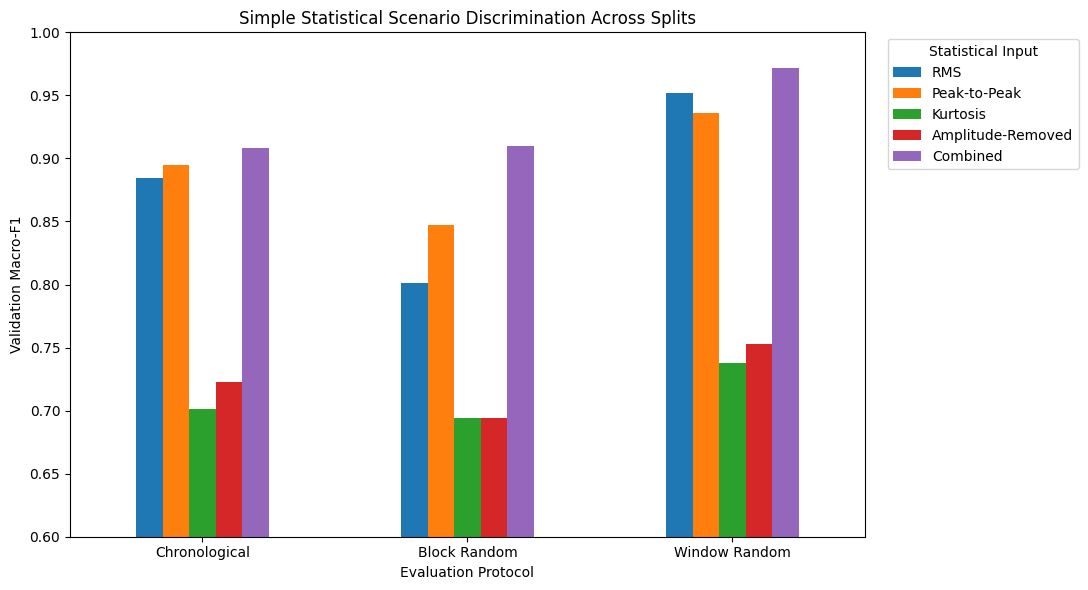

In [73]:
# ============================================================
# 9.2 Cross-Split Comparison Plot
# ============================================================

plot_df = cross_split_results.set_index("split")

ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Validation Macro-F1")
plt.xlabel("Evaluation Protocol")
plt.title(
    "Simple Statistical Scenario Discrimination Across Splits"
)

plt.ylim(0.60, 1.00)
plt.xticks(rotation=0)
plt.legend(
    title="Statistical Input",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [74]:
# ============================================================
# 9.3 Effect of Amplitude Removal
# ============================================================

amplitude_effect_df = cross_split_results[
    ["split", "Combined", "Amplitude-Removed"]
].copy()

amplitude_effect_df["F1_drop_after_amplitude_removal"] = (
    amplitude_effect_df["Combined"]
    - amplitude_effect_df["Amplitude-Removed"]
)

display(
    amplitude_effect_df.round(4)
)

,split,Combined,Amplitude-Removed,F1_drop_after_amplitude_removal
0,Chronological,0.9080,0.7226,0.1854
1,Block Random,0.9099,0.6943,0.2156
2,Window Random,0.9720,0.7531,0.2189


## 9.4 Summary

Simple window-level statistical features showed strong scenario-discriminative
information under all three evaluation protocols.

The combined statistical representation achieved similar Validation Macro-F1
under the Chronological and Block Random protocols (approximately 0.91), while
performance increased substantially under Window Random (0.972).

Amplitude-related features were particularly informative. RMS alone achieved a
Macro-F1 of 0.952 under Window Random, and Peak-to-Peak achieved 0.936.

Removing absolute amplitude information reduced performance substantially under
all three protocols, with Macro-F1 decreasing to approximately 0.69–0.75.
This indicates that amplitude-related information contributes strongly to the
simple statistical separability of the scenarios.

However, non-amplitude statistical information remained discriminative above
chance level.

These results do not by themselves establish acquisition leakage or model
shortcut learning. They show that the dataset contains strong and stable
scenario-specific statistical signatures, and that Window Random evaluation
makes these simple signatures particularly transferable between Train and
Validation.